In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

CLEAN_DIR = "clean"

In [3]:
import os

tables = {}
for f in os.listdir(CLEAN_DIR):
    if f.endswith(".csv"):
        name = f.replace(".csv", "")
        tables[name] = pd.read_csv(os.path.join(CLEAN_DIR, f))

print(f"Loaded {len(tables)} tables:")
for name in sorted(tables.keys()):
    print(f"  {name} — {tables[name].shape}")

Loaded 25 tables:
  charging_by_organization — (3, 5)
  charging_city_highway — (14, 4)
  charging_district — (31, 4)
  charging_expressway — (25, 5)
  charging_fame2_detail — (108, 4)
  charging_national_highway — (90, 3)
  charging_state_simple — (117, 4)
  ev_registration_by_category — (30, 6)
  ev_registration_trends — (27, 4)
  global_ev_share — (20, 4)
  manufacturer_awards — (2, 5)
  manufacturer_vehicle_class — (25, 4)
  sales_category_growth — (4, 5)
  sales_domestic_by_year — (9, 5)
  sales_wheeler_totals — (3, 3)
  scheme_budget_by_year — (20, 4)
  scheme_energy_requirement — (6, 3)
  scheme_evs_supported — (3, 4)
  scheme_pmedrive_budget — (6, 3)
  scheme_subsidy_amount — (4, 4)
  scheme_vehicle_targets — (4, 4)
  state_electric_split — (68, 4)
  state_simple_counts — (104, 4)
  state_vehicle_category — (288, 4)
  state_vehicle_type — (510, 4)


## Q1: How has EV registration grown over time?

In [4]:
df_reg = tables["ev_registration_trends"]
print(df_reg["year"].unique())

['2019' '2020' '2021' '2014' '2015' '2016' '2017' '2018' '2022'
 '2023 (till 15-03-2023)' '2023 (Till 19-03-2023)' '2023' '2024' '2019-20'
 '2020-21' '2021-22' '2022-23' '2023-24']


In [5]:
df_reg = tables["ev_registration_trends"].copy()

# extract a clean 4-digit year for sorting/plotting purposes (keeps fiscal/partial labels visible in the actual x-axis text)
df_reg["year_sort"] = df_reg["year"].str.extract(r'(\d{4})').astype(int)
df_reg = df_reg.sort_values(["source_file", "year_sort"])

df_reg

,year,ev_count,source_file,pct_change,year_sort
0,2019,161314,RS_Session_255_AU_749.C.csv,NaN,2019
1,2020,119648,RS_Session_255_AU_749.C.csv,NaN,2020
2,2019,164852,RS_Session_256_AS_154.A.csv,NaN,2019
3,2020,123528,RS_Session_256_AS_154.A.csv,-25.07,2020
4,2021,324840,RS_Session_256_AS_154.A.csv,162.97,2021
5,2014,2391,RS_Session_259_AU_2032_A.csv,NaN,2014
6,2015,7790,RS_Session_259_AU_2032_A.csv,NaN,2015
7,2016,49622,RS_Session_259_AU_2032_A.csv,NaN,2016
8,2017,86720,RS_Session_259_AU_2032_A.csv,NaN,2017
9,2018,129125,RS_Session_259_AU_2032_A.csv,NaN,2018


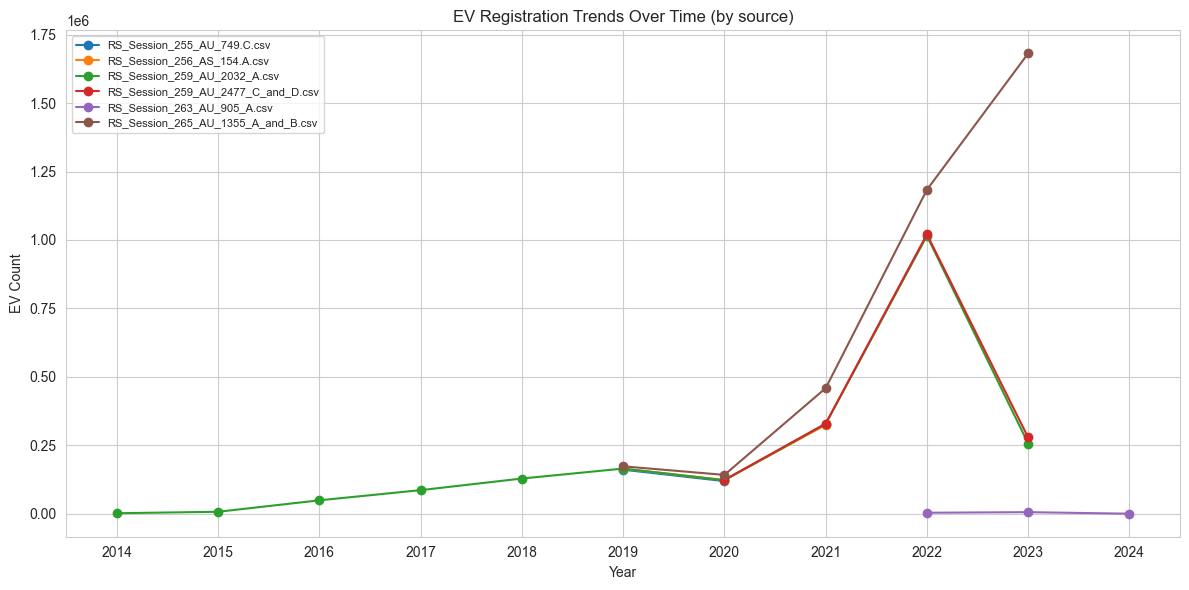

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for source, group in df_reg.groupby("source_file"):
    ax.plot(group["year_sort"], group["ev_count"], marker='o', label=source)

ax.set_xlabel("Year")
ax.set_ylabel("EV Count")
ax.set_title("EV Registration Trends Over Time (by source)")
ax.legend(fontsize=8, loc='upper left')
ax.set_xticks(sorted(df_reg["year_sort"].unique()))
plt.tight_layout()
plt.show()

### Interpretation

- EV registrations grew steadily from 2014 (2,391) through 2019 (~165,000),
  then show a sharp acceleration from 2021 onward across all sources.
- Calendar-year and fiscal-year reporting don't align, and this matters:
  the fiscal-year series shows continuous growth to 1.68M by 2023-24, while
  calendar-year series show a peak around 1.02M in 2022 followed by an
  apparent drop to ~0.28M in 2023. This is very likely a period-mismatch
  artifact (fiscal year spans Apr-Mar, calendar year spans Jan-Dec) rather
  than a genuine adoption decline — worth flagging as a data limitation
  rather than treating the "2023 drop" as a real trend.
- One source (RS_Session_263_AU_905_A) reports values on a much smaller
  scale (4,178-6,312) than the others — likely tracking a narrower segment
  rather than all-India totals; excluded from headline trend conclusions.
- **Takeaway:** the *direction* of growth (strong, accelerating from 2021)
  is consistent and reliable across sources. The *exact 2023 figure* is not
  reliable without knowing which reporting period each source actually
  used — this should be caveated in the final report rather than picking
  one number as "the" 2023 total.

## Q2: Which vehicle categories are adopting EVs fastest?

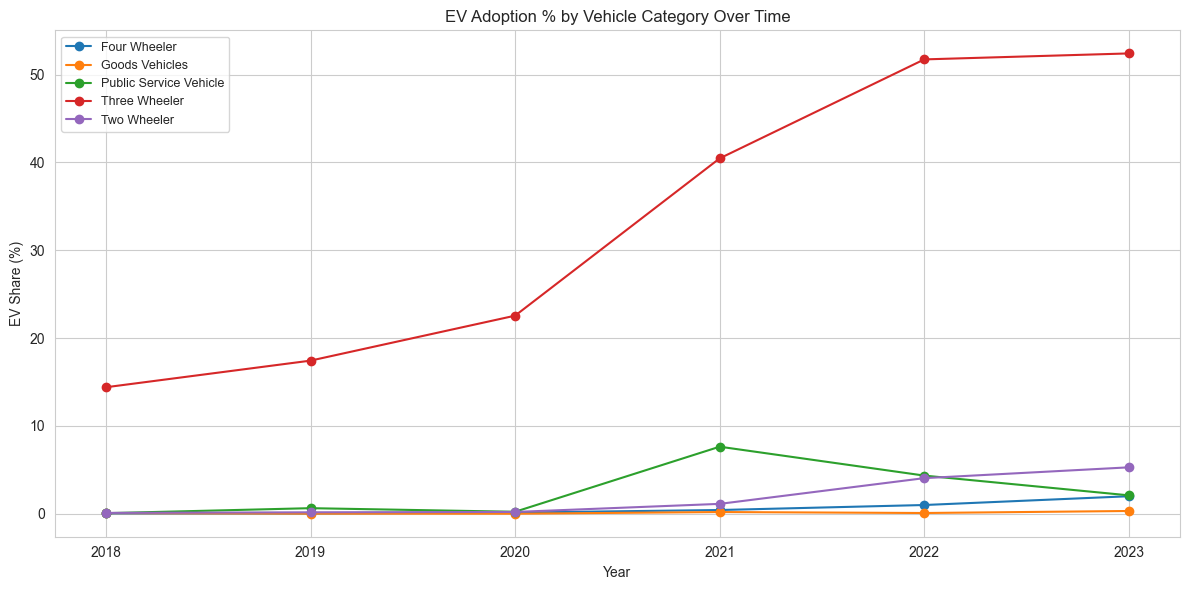

In [8]:
df_cat = tables["ev_registration_by_category"].copy()
df_cat["year_sort"] = df_cat["year"].str.extract(r'(\d{4})').astype(int)
df_cat = df_cat.sort_values(["vehicle_category", "year_sort"])

fig, ax = plt.subplots(figsize=(12, 6))

for category, group in df_cat.groupby("vehicle_category"):
    ax.plot(group["year_sort"], group["ev_pct"], marker='o', label=category)

ax.set_xlabel("Year")
ax.set_ylabel("EV Share (%)")
ax.set_title("EV Adoption % by Vehicle Category Over Time")
ax.legend(fontsize=9)
ax.set_xticks(sorted(df_cat["year_sort"].unique()))
plt.tight_layout()
plt.show()

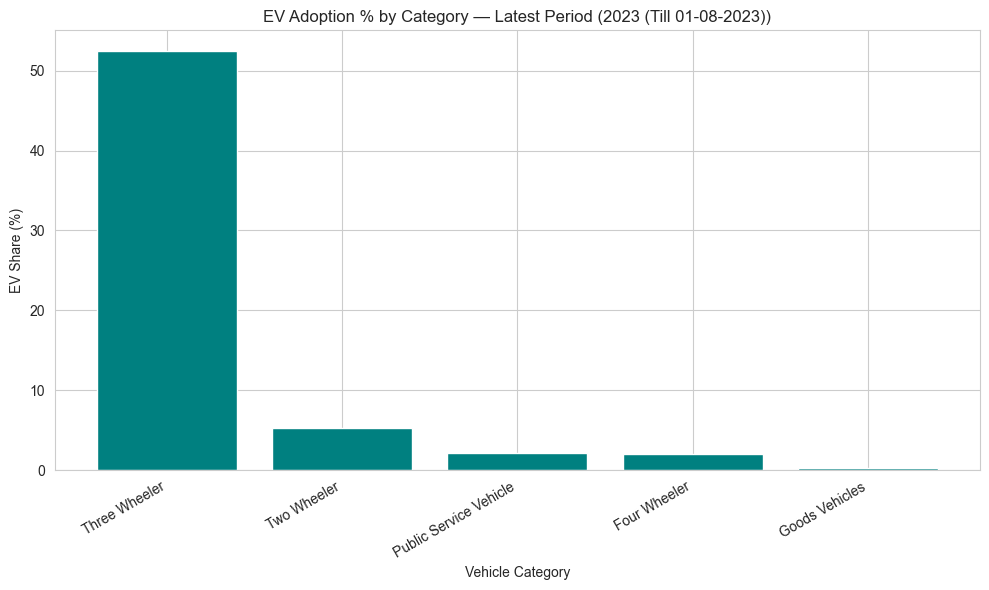

In [9]:
latest_year = df_cat["year_sort"].max()
df_latest = df_cat[df_cat["year_sort"] == latest_year].sort_values("ev_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_latest["vehicle_category"], df_latest["ev_pct"], color='teal')
ax.set_xlabel("Vehicle Category")
ax.set_ylabel("EV Share (%)")
ax.set_title(f"EV Adoption % by Category — Latest Period ({df_cat[df_cat['year_sort']==latest_year]['year'].iloc[0]})")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Interpretation

- **Three-wheelers are the dominant EV adopter by a wide margin** — EV share
  rose from 14.4% (2018) to 52.4% (2023), with the steepest acceleration
  between 2020 and 2021 (22.6% → 40.6%). No other category comes close.
- **Two-wheelers and Four-wheelers** show slow, steady growth reaching only
  5.3% and ~2.1% respectively by 2023 — real progress, but an order of
  magnitude behind three-wheelers.
- **Public Service Vehicles show an unusual pattern**: EV share spiked to
  7.6% in 2021 (briefly the second-highest category that year) before
  declining to 4.3% (2022) and 2.1% (2023) — the only category with a
  non-monotonic trend. This may reflect a small base effect (a handful of
  EV additions/removals having an outsized % impact on a small fleet) or a
  genuine shift in fleet composition — worth a note rather than a firm
  conclusion, since the underlying vehicle counts should be checked before
  reading too much into it.
- **Goods Vehicles remain essentially flat and near-zero** throughout —
  the least-adopted category by far.
- **Takeaway:** confirms the three-wheeler-led adoption pattern seen
  elsewhere in the data, but the Public Service Vehicle anomaly adds a
  nuance worth investigating further if time permits — it's the one
  category that doesn't fit the "steady growth" story.